In [1]:
#Imports
import torch
import random
import os
from numpy import genfromtxt
import numpy as np
import matplotlib.pyplot as plt
import csv
import numpy as np
import matplotlib.pyplot as plt
import jax.numpy as jnp
import pandas as pd
import diffrax
import equinox as eqx
import jax
import jax.nn as jnn
import jax.random as jr
import optax
from tqdm import tqdm

In [2]:
# Load experimental data
#data_1 = genfromtxt(os.path.join('ambr/ambr_run1_140323_13-18.csv'), delimiter=',', names=True)
source = os.path.join('ambr/ambr_run1_140323_13-18.csv')
source2 = os.path.join('ambr/ambr_run1_140323_19-24.csv')
source3 = os.path.join('ambr/ambr_run2_030523_5-10.csv')
source4 = os.path.join('ambr/ambr_run2_030523_11-16.csv')
source5 = os.path.join('ambr/ambr_run2_030523_17-22.csv')
source6 = os.path.join('ambr/ambr_run2_030523_23-24.csv')
data_1 = pd.read_csv(source)
data_2 = pd.read_csv(source2)
data_3 = pd.read_csv(source3)
data_4 = pd.read_csv(source4)
data_5 = pd.read_csv(source5)
data_6 = pd.read_csv(source6)

In [3]:
#20 different conditions for the different bioreactors
mode = ["Acid volume pumped", 
        "Air flow", 
        "Base volume pumped", 
        "Bioreactor pressure reading", 
        "CER", 
        "DO", 
        "Feed#1 flow rate", 
        "Feed#1 volume pumped", 
        "Feed#2 flow rate", 
        "Feed#2 volume pumped",
        "Foam sensor",
        "Off-gas CO2",
        "Optical density",
        "OUR",
        "pH",
        "Reflectance",
        "RQ",
        "Sampling events",
        "Stir speed",
        "Temperature",
        "Volume"]

j = mode[12] #Optical density

"""Notes to self (Observing how good are these data)
        Nothing in 6th-9th mode (neither 13 or 16... since data are missing) #What happens with 17 ???
        Most interesting ones : 5/10/14 - 3/12 - 15 - 4 - 
        The 18th dataset could be interesting but the risk of overfitting makes me a bit sceptical...
        It seems like every bioreactor is positively proportionnal to each other"""

'Notes to self (Observing how good are these data)\n        Nothing in 6th-9th mode (neither 13 or 16... since data are missing) #What happens with 17 ???\n        Most interesting ones : 5/10/14 - 3/12 - 15 - 4 - \n        The 18th dataset could be interesting but the risk of overfitting makes me a bit sceptical...\n        It seems like every bioreactor is positively proportionnal to each other'

In [ ]:
train = "extrapolation" #Type classic - extrapolation - interpolation

l_3 = [i for i in data_3.columns if j in i]
l_1 = [i for i in data_1.columns if j in i]
l_2 = [i for i in data_2.columns if j in i]
l_4 = [i for i in data_4.columns if j in i]

data = pd.concat([data_1[data_1[l_1].columns[5:7]]], axis=1) #Select the 18th bioreactor

end_l = 150 #End of the lag phase
end_d = 400 #End of data values

ind = [i for i in range(end_d,data.shape[0])] #Get rid of the data beyond 400h (because NaN values)
data = data.drop(ind)

train_section = ((end_d - end_l)//3)*2 #Take 2/3 of the data

ind_2 = [i for i in range(end_l,end_d-1) if i%25!=0] #For interpolation, take a value every 25 values
ind_1 = [i for i in range(end_l,end_d-1) if i%25==0] #For extrapolation
ind_0 = [i for i in range(0,end_l)] #Get rid of the lag phase

ind_train = [i for i in range(end_l + train_section, end_d)]
ind_test = [i for i in range(end_l, end_l + train_section)]

Batch_2 = data.drop(ind_0)*0.4267
Batch_0 = Batch_2
if train == "extrapolation":
    Batch_2 = Batch_2.drop(ind_train) #
    Batch_extra = Batch_0.drop(ind_test)
if train == "interpolation":
    Batch_2 = Batch_2.drop(ind_2)

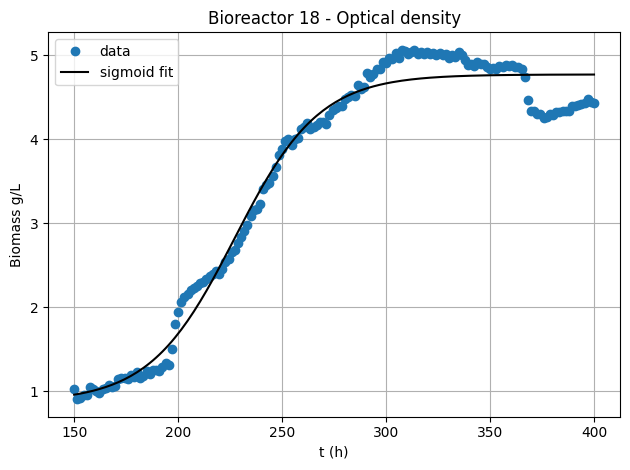

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

#Non-Linear Regression of the data with a sigmoid function

def sigmoid(t, L, k, t0, b):
    return b + L / (1 + np.exp(-k * (t - t0)))

t_inter = np.linspace(end_l, 400, len(Batch_2))

y_data = Batch_2["Bioreactor 18 - Optical density"]

# Initial guesses
b0 = np.min(y_data)
L0 = np.max(y_data) - np.min(y_data)
k0 = 0.05
t0_guess = t_inter[np.argmax(np.gradient(y_data))]

p0 = [L0, k0, t0_guess, b0]

params, _ = curve_fit(sigmoid, t_inter, y_data, p0=p0, maxfev=10000)

y_fit = sigmoid(t_inter, *params)

plt.plot(t_inter, y_data, 'o', label="data")
plt.plot(t_inter, y_fit, label="sigmoid fit", c="black")

plt.title("Bioreactor 18 - Optical density")
plt.xlabel("t (h)")
plt.ylabel("Biomass g/L")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

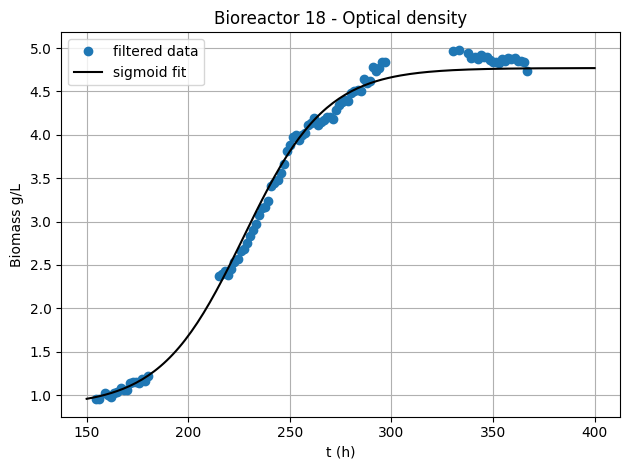

In [6]:
#Cleaning : Get rid of the data that are to different

diff = np.abs(y_fit - y_data) / np.abs(y_fit)

mask = diff <= 0.05   # keep points with relative error <= 1%

t_clean = t_inter[mask]
y_clean = y_data[mask]

plt.plot(t_clean, y_clean, 'o', label="filtered data")
plt.plot(t_inter, y_fit, label="sigmoid fit", c="black")

plt.title("Bioreactor 18 - Optical density")
plt.xlabel("t (h)")
plt.ylabel("Biomass g/L")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
y0 = torch.tensor(y_clean.iloc[0], dtype=torch.float32)

Bio_react = jnp.asarray(y_clean, dtype=jnp.float32)

Batch_2 = jnp.asarray(Batch_2, dtype=jnp.float32)
Batch_0 = jnp.asarray(Batch_0, dtype=jnp.float32)

train_idx = np.linspace(end_l, end_l + train_section, len(y_clean))
test_idx = np.linspace(end_l, end_d, len(Batch_0))

#inter_idx = np.array([i for i in range(end_d) if i % 25 != 0]) #Timestep for interpolation
#t_smooth = np.arange(50, 600, 1)
t_s = np.arange(0, 399, 1)

t_clean = torch.tensor(t_clean, dtype=torch.float32)

ts = jnp.asarray(train_idx, dtype=jnp.float32)
t_all = jnp.asarray(test_idx, dtype=jnp.float32)

#t_inter = jnp.asarray(inter_idx, dtype=jnp.float32)
Bio_react = jnp.expand_dims(Bio_react, axis=1)

In [30]:
class Func(eqx.Module):
    out_scale: jax.Array
    mlp: eqx.nn.MLP

    def __init__(self, data_size, width_size, depth, *, key, **kwargs):
        super().__init__(**kwargs)
        self.out_scale = jnp.array(1.0)
        self.mlp = eqx.nn.MLP(
            in_size=data_size,
            out_size=data_size,
            width_size=width_size,
            depth=depth,
            activation=jnn.softplus,
            final_activation=jax.nn.tanh,
            key=key,
        )

    def __call__(self, t, y, args):
        return self.out_scale * self.mlp(y)


class NeuralODE(eqx.Module):
    func: Func

    def __init__(self, data_size, width_size, depth, *, key, **kwargs):
        super().__init__(**kwargs)
        self.func = Func(data_size, width_size, depth, key=key)

    def __call__(self, ts, y0):#######################################################################
        solution = diffrax.diffeqsolve(
            diffrax.ODETerm(self.func),
            diffrax.Dopri5(),
            t0=ts[0],
            t1=ts[-1],
            dt0=ts[1] - ts[0],
            y0=y0,
            stepsize_controller=diffrax.PIDController(rtol=1e-6, atol=1e-8),
            adjoint=diffrax.DirectAdjoint(),
            max_steps = 1000000,
            saveat=diffrax.SaveAt(ts=ts),
        )
        return solution.ys

lr=1e-5
width_size=2*Batch_2.shape[1] # Number of neurons per layer
depth=2*Batch_2.shape[1] # Number of layers

def main(t, variable_data_list, n_epochs, seed=5678, plot=True):
    ts = jnp.asarray(t, dtype=jnp.float32)

    key = jr.PRNGKey(seed)
    data_key, model_key, loader_key = jr.split(key, 3)

    length_size, data_size = jnp.asarray(variable_data_list, dtype=jnp.float32).shape
    ys = jnp.asarray(variable_data_list, dtype=jnp.float32)

    model = NeuralODE(data_size, width_size, depth, key=model_key)
    optim = optax.adabelief(lr)
    opt_state = optim.init(eqx.filter(model, eqx.is_inexact_array))

    @eqx.filter_value_and_grad
    def grad_loss(model, ti, yi):
        y_pred = model(ti, yi[0])   # shape (T, data_size)
        sigma = 1.0
        loss_classic = jnp.mean(((yi - y_pred) / sigma) ** 2)
        negativity_loss = jnp.mean(jnp.maximum(0.0, -y_pred) ** 2)

        # combine losses if desired
        return loss_classic + 0.0 * negativity_loss

    @eqx.filter_jit
    def make_step(ti, yi, model, opt_state):
        loss, grads = grad_loss(model, ti, yi)
        updates, opt_state = optim.update(grads, opt_state, model)
        model = eqx.apply_updates(model, updates)
        return loss, model, opt_state

    loss_l = []
    loss_inter = []
    n_vars = variable_data_list.shape[1]
    R2_scores = [[] for _ in range(n_vars)]

    y_true = torch.tensor(np.asarray(variable_data_list), dtype=torch.float32)

    for epoch in tqdm(range(n_epochs)):
        loss, model, opt_state = make_step(ts, ys, model, opt_state)

        model_i = model(t_inter, ys[0])
        #model_i = model(t_s, ys[0])

        #loss_i = jnp.mean((Batch_2 - model_i) ** 2)
        
        loss_l.append(float(loss))
        #loss_inter.append(float(loss_i))

        # recompute prediction AFTER model update
        y_pred = torch.tensor(np.asarray(model(ts, ys[0])), dtype=torch.float32)

        for i in range(n_vars):
            ss_res = torch.sum((y_true[:, i] - y_pred[:, i]) ** 2)
            ss_tot = torch.sum((y_true[:, i] - torch.mean(y_true[:, i])) ** 2)
            r2 = 1 - ss_res / (ss_tot + 1e-12)
            R2_scores[i].append(float(r2))

    return loss_l, R2_scores, ts, ys, model

In [ ]:
n_epochs = 100000 #Max is 240000

loss, R, ts, ys, model = main(t_clean, Bio_react, n_epochs)

t_all = jnp.asarray(t_inter, dtype=jnp.float32)
model_y = model(t_all, ys[0])

  0%|          | 0/100000 [00:00<?, ?it/s]

 50%|█████     | 50341/100000 [08:57<09:52, 83.76it/s] 

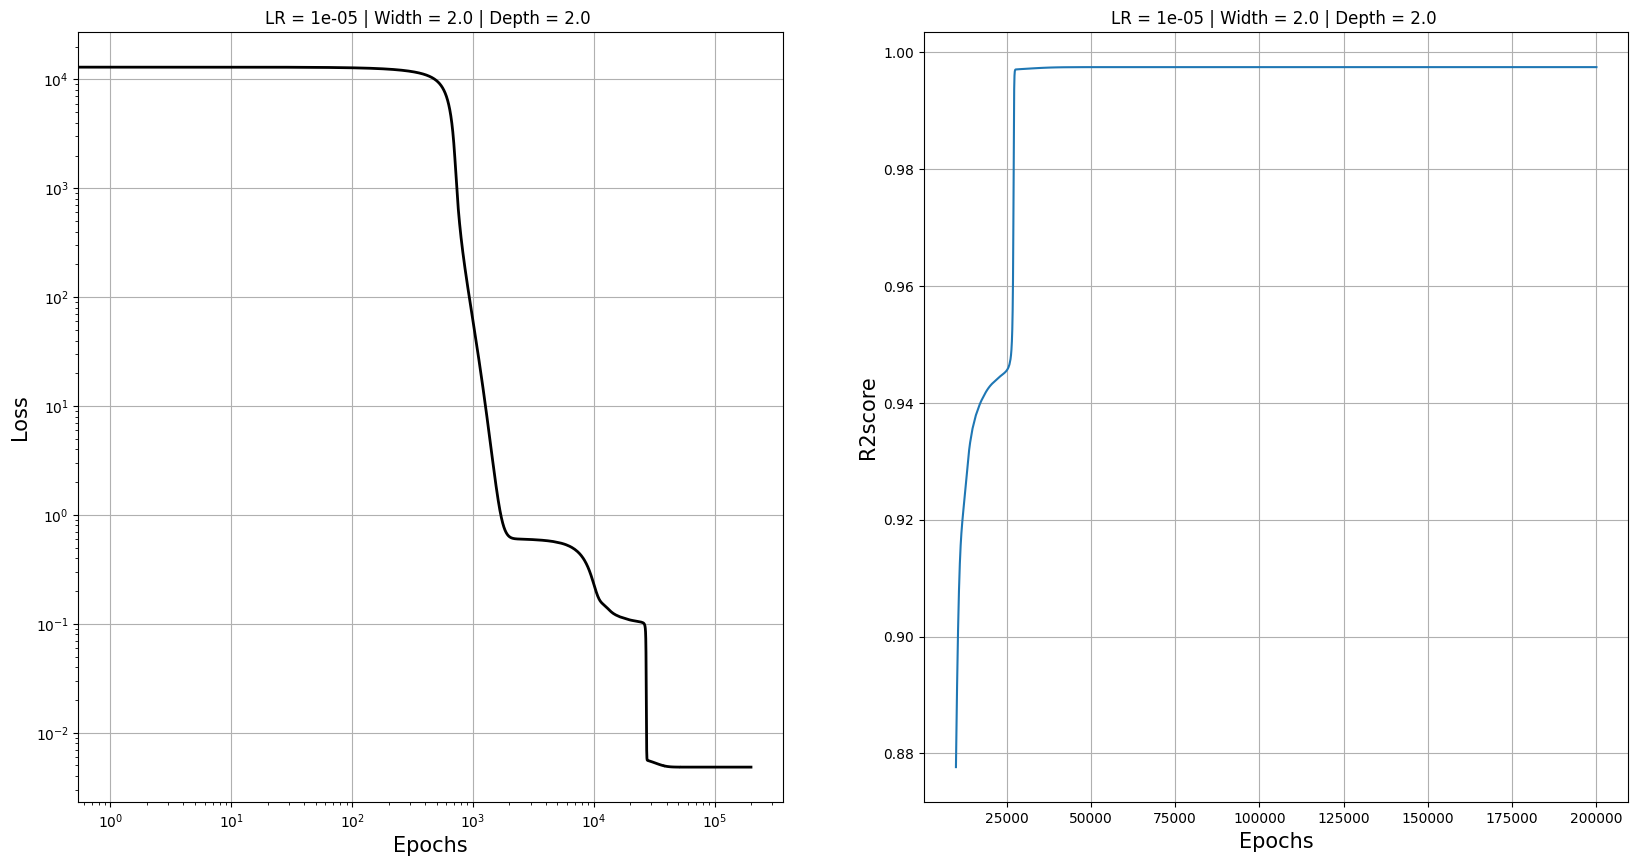

In [28]:
fig, axs = plt.subplots(1, 2, figsize=(20, 10))

axs[0].plot(loss, color = 'black',linewidth=2)
axs[0].grid(True)
axs[0].set_title(f"LR = {lr} | Width = {width_size:.1f} | Depth = {depth:.1f} ")
axs[0].set_xlabel('Epochs',fontsize=15)
axs[0].set_ylabel('Loss',fontsize=15)
axs[0].set_xscale('log')
axs[0].set_yscale('log')

start_r = 10000
t_r = np.arange(start_r, n_epochs, 1)
"""
axs[1].plot(loss_inter, color = 'black',linewidth=2)
axs[1].grid(True)
axs[1].set_title(f"LR = {lr} | Width = {width_size:.1f} | Depth = {depth:.1f} ")
axs[1].set_xlabel('Epochs',fontsize=15)
axs[1].set_ylabel('Loss inter',fontsize=15)
axs[1].set_xscale('log')
axs[1].set_yscale('log')"""


axs[1].plot(t_r, R[0][start_r:])
axs[1].grid(True)
axs[1].set_title(f"LR = {lr} | Width = {width_size:.1f} | Depth = {depth:.1f} ")
axs[1].set_xlabel('Epochs',fontsize=15)
axs[1].set_ylabel('R2score',fontsize=15)

plt.show()

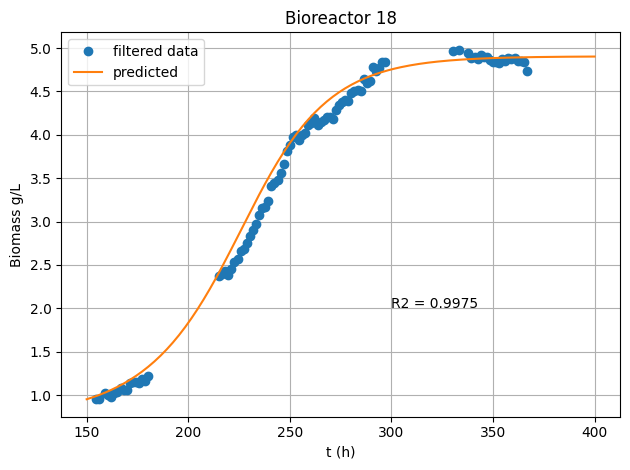

<Figure size 640x480 with 0 Axes>

In [19]:
## Plot the predicted variables

plt.plot(t_clean, y_clean, 'o', label="filtered data")
plt.plot(t_all, model_y[:, 0], label="predicted")
plt.title("Bioreactor 18")
plt.xlabel("t (h)")
plt.ylabel("Biomass g/L")
plt.grid(True)
plt.legend()
plt.text(300, 2,f"R2 = {R[0][n_epochs-1]:.4f}")
plt.tight_layout()
plt.show()
plt.tight_layout()
plt.show()

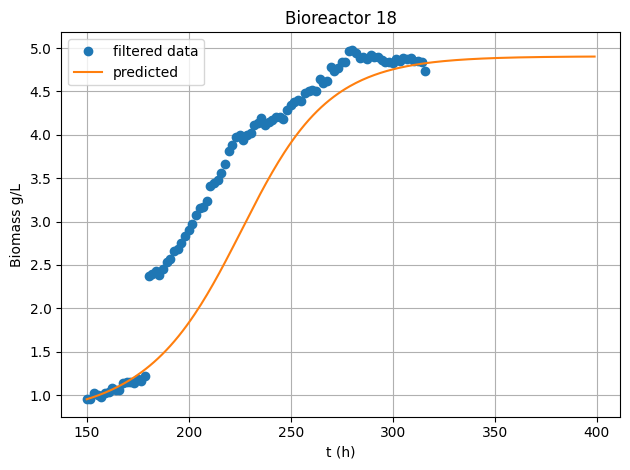

<Figure size 640x480 with 0 Axes>

In [29]:
## Plot the predicted variables
extra_idx = np.arange(end_l, 400, 1)
model_extra = model(extra_idx, ys[0])

plt.plot(train_idx, y_clean, 'o', label="filtered data")
plt.plot(extra_idx, model_extra[:, 0], label="predicted")
plt.title("Bioreactor 18")
plt.xlabel("t (h)")
plt.ylabel("Biomass g/L")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
plt.tight_layout()
plt.show()


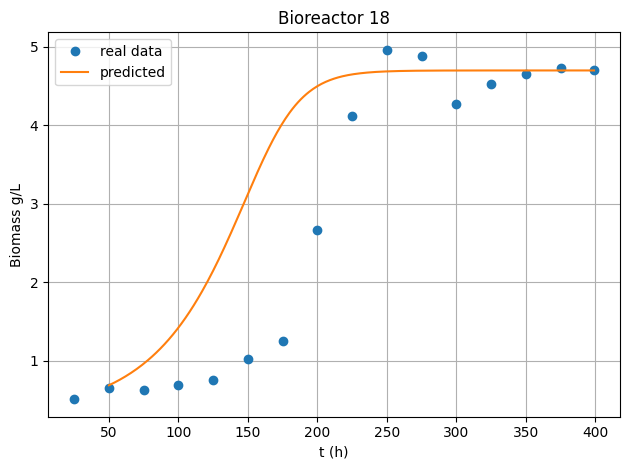

<Figure size 640x480 with 0 Axes>

In [ ]:
## Plot the predicted variables
t_smooth = np.arange(50, 400, 1)
model_inter = model(t_smooth, ys[0])

plt.plot(Batch_2, "o", label="real data")
plt.plot(t_smooth, model_inter, label="predicted")
plt.title("Bioreactor 18")
plt.xlabel("t (h)")
plt.ylabel("Biomass g/L")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
plt.tight_layout()
plt.show()
